# 3I - Interpretacao integrada da Fase 3 (Pacifico; NOAA/ONI local)

**Pergunta especifica.** Depois de 3A-3H/3K, qual e a leitura fisica defensavel do Nino 3.4, quais evidencias entram no parecer, como ficam as classes NOAA (`fraco`, `moderado`, `forte`, `muito_forte`), e como ler a janela 2026?

**Objetivo.** Consolidar evidencias/limites em saida unica rastreavel a tabelas ja materializadas.

**Justificativa.** Evita interpretacao solta e elimina classificacoes antigas por percentis. **Escopo estritamente Pacifico** - indices atlanticos foram removidos da Fase 3.

**Metodologia.** Le features/statistics; usa regra NOAA/ONI compativel na OISST local; evento = media movel 3 meses >=+0.5 C por 5+ estacoes sobrepostas; intensidade = pico dessa media movel.

**Saidas.** `phase3I_conclusoes_decisao.csv`, `phase3I_classificacao_noaa_oni.csv`, `phase3I_medias_classes_noaa.csv`, `phase3I_estado_2026.csv`, figura-sintese.


In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fase3_utils as u
d3=pd.read_csv(u.STATS/'phase3D_ranking_significativo.csv').set_index('variavel')
e3=pd.read_csv(u.STATS/'phase3E_estabilidade.csv').set_index('variavel')
assert not any('atl' in v for v in d3.index), 'Atlantico ainda presente!'
print('Variaveis no parecer (todas Pacifico):',list(d3.index))
bloco={'tilt_m':'recarga/subsuperficie','ssh_m':'recarga/subsuperficie','ohc_0_300':'recarga/subsuperficie','ohc_0_700':'recarga/subsuperficie','d20_m':'recarga/subsuperficie','wwv':'recarga/subsuperficie','tau_x_anom_nino34_pa':'vento/acoplamento','dhw_cweek_0p5_12w':'calor acumulado'}
rows=[]
for v in d3.index:
    est=bool(e3.loc[v,'estavel']) if v in e3.index else False
    lag=int(d3.loc[v,'lag_semanas'])
    papel='estado simultaneo/curto prazo' if lag<=1 else 'precursor de medio prazo'
    status='entra' if est else 'entra como ressalva (regime-dependente)'
    rows.append({'variavel':v,'rotulo':u.var_label(v,short=True),'bloco':bloco.get(v,'-'),'lag_semanas':lag,'r':round(d3.loc[v,'r'],3),'estavel_3E':est,'papel':papel,'uso_parecer':status})
conc=pd.DataFrame(rows); u.save_table(conc,'phase3I_conclusoes_decisao.csv',index=False); conc


Variaveis no parecer (todas Pacifico): ['oni_12w_mean_c', 'dhw_cweek_0p5_12w', 'tilt_m', 'ssh_m', 'ohc_0_300', 'ohc_0_700', 'd20_m', 'wwv', 'elnino_thermal_persistent_20w', 'tau_x_anom_nino34_pa']
[tabela] data\processed\parquet\statistics\phase3I_conclusoes_decisao.csv


,variavel,rotulo,bloco,lag_semanas,r,estavel_3E,papel,uso_parecer
0,oni_12w_mean_c,SSTA 12w,-,0,0.920,True,estado simultaneo/curto prazo,entra
1,dhw_cweek_0p5_12w,DHW >=0.5C,calor acumulado,0,0.775,True,estado simultaneo/curto prazo,entra
2,tilt_m,Tilt,recarga/subsuperficie,0,0.772,True,estado simultaneo/curto prazo,entra
3,ssh_m,SSH,recarga/subsuperficie,6,0.755,True,precursor de medio prazo,entra
4,ohc_0_300,OHC0-300,recarga/subsuperficie,6,0.738,True,precursor de medio prazo,entra
5,ohc_0_700,OHC0-700,recarga/subsuperficie,6,0.701,True,precursor de medio prazo,entra
6,d20_m,D20,recarga/subsuperficie,15,0.545,True,precursor de medio prazo,entra
7,wwv,WWV,recarga/subsuperficie,20,0.516,False,precursor de medio prazo,entra como ressalva (regime-dependente)
8,elnino_thermal_persistent_20w,Persist. 20w,-,0,0.513,True,estado simultaneo/curto prazo,entra
9,tau_x_anom_nino34_pa,tau_x anom.,vento/acoplamento,1,0.478,True,estado simultaneo/curto prazo,entra


In [2]:
ev_all = u.events_noaa()
counts = ev_all['classe_noaa'].value_counts().to_dict()
classes = u.elnino_mean_group_table()[['grupo','rotulo','definicao']].copy()
classes['n_eventos'] = classes['grupo'].map(lambda g: int(counts.get(g,0)))
classes['limiar_evento_oni_c'] = 0.5
classes['criterio_temporal'] = 'media movel de 3 meses >=+0.5 C por 5+ estacoes sobrepostas'
classes['fonte_metodologica'] = 'NOAA/CPC ONI historico; aplicado localmente a OISST NINO-BRASIL'
u.save_table(classes,'phase3I_classificacao_noaa_oni.csv',index=False)
print(classes.to_string(index=False))


[tabela] data\processed\parquet\statistics\phase3I_classificacao_noaa_oni.csv
      grupo                                     rotulo                                                           definicao  n_eventos  limiar_evento_oni_c                                           criterio_temporal                                              fonte_metodologica
      fraco         El Nino fraco (0.5 <= ONI < 1.0 C)      pico da media movel de 3 meses na Nino 3.4 entre +0.5 e +0.9 C          4                  0.5 media movel de 3 meses >=+0.5 C por 5+ estacoes sobrepostas NOAA/CPC ONI historico; aplicado localmente a OISST NINO-BRASIL
   moderado      El Nino moderado (1.0 <= ONI < 1.5 C)      pico da media movel de 3 meses na Nino 3.4 entre +1.0 e +1.4 C          2                  0.5 media movel de 3 meses >=+0.5 C por 5+ estacoes sobrepostas NOAA/CPC ONI historico; aplicado localmente a OISST NINO-BRASIL
      forte         El Nino forte (1.5 <= ONI < 2.0 C)      pico da media movel de 3 

In [3]:
# medias executivas por classe NOAA/ONI local
taxas = pd.read_csv(u.STATS / 'phase3B_eventos_taxas.csv')
dhw_evt = pd.read_csv(u.STATS / 'phase3G_eventos_dhw.csv')
base_media = taxas.merge(
    dhw_evt[['event_id', 'dhw_no_pico_ssta', 'dhw_maximo', 'defasagem_pico_dhw_sem']],
    on='event_id',
    how='left',
)

def _stat(frame, col, func='mean', ndigits=3):
    s = frame[col].dropna()
    if s.empty:
        return np.nan
    val = getattr(s, func)()
    return round(float(val), ndigits)

def _media_row(grupo, frame):
    return {
        'grupo': grupo,
        'n_eventos': int(len(frame)),
        'oni_pico_medio_c': _stat(frame, 'oni_pico_c', 'mean', 3),
        'oni_pico_min_c': _stat(frame, 'oni_pico_c', 'min', 3),
        'oni_pico_max_c': _stat(frame, 'oni_pico_c', 'max', 3),
        'duracao_media_estacoes_oni': _stat(frame, 'duracao_estacoes_oni', 'mean', 2),
        'crescimento_medio_c_mes': _stat(frame, 'crescimento_c_por_mes', 'mean', 3),
        'decaimento_medio_c_mes': _stat(frame, 'decaimento_c_por_mes', 'mean', 3),
        'dhw_pico_ssta_medio_c_weeks': _stat(frame, 'dhw_no_pico_ssta', 'mean', 2),
        'dhw_maximo_medio_c_weeks': _stat(frame, 'dhw_maximo', 'mean', 2),
        'defasagem_pico_dhw_media_sem': _stat(frame, 'defasagem_pico_dhw_sem', 'mean', 2),
    }

group_frames = {g: base_media.query('classe == @g') for g in u.ELNINO_MEAN_GROUP_ORDER}
meta = u.elnino_mean_group_table()[['grupo', 'rotulo_curto', 'rotulo', 'definicao']]
media = meta.merge(pd.DataFrame([_media_row(g, group_frames[g]) for g in u.ELNINO_MEAN_GROUP_ORDER]), on='grupo', how='left')
u.save_table(media, 'phase3I_medias_classes_noaa.csv', index=False)
print(media.to_string(index=False))


[tabela] data\processed\parquet\statistics\phase3I_medias_classes_noaa.csv
      grupo rotulo_curto                                     rotulo                                                           definicao  n_eventos  oni_pico_medio_c  oni_pico_min_c  oni_pico_max_c  duracao_media_estacoes_oni  crescimento_medio_c_mes  decaimento_medio_c_mes  dhw_pico_ssta_medio_c_weeks  dhw_maximo_medio_c_weeks  defasagem_pico_dhw_media_sem
      fraco        Fraco         El Nino fraco (0.5 <= ONI < 1.0 C)      pico da media movel de 3 meses na Nino 3.4 entre +0.5 e +0.9 C          4             0.858           0.652           0.968                        6.00                    0.224                  -0.027                         4.91                     10.12                          6.25
   moderado     Moderado      El Nino moderado (1.0 <= ONI < 1.5 C)      pico da media movel de 3 meses na Nino 3.4 entre +1.0 e +1.4 C          2             1.212           1.211           1.213           

In [4]:
daily = u.load_daily_nino34()
dhw_daily = u.load_dhw()
last = daily.index.max()
latest_dhw = dhw_daily.loc[dhw_daily.index <= last].iloc[-1]
monthly = pd.read_csv(u.FEAT / 'nino34_monthly_oisst.csv', parse_dates=['time'])
complete = monthly[monthly.get('month_complete', True).astype(bool)].copy()
last_complete = complete.iloc[-1]

persistent = bool(latest_dhw['elnino_thermal_persistent_20w'])
run_weeks = float(latest_dhw['oni_12w_run_ge_0p5_weeks'])
oni_12w = float(latest_dhw['oni_12w_mean_c'])
reading = (
    'criterio termico NOAA/ONI local atendido por >=20 semanas consecutivas; verificar acoplamento atmosferico'
    if persistent else
    'criterio termico NOAA/ONI local ainda nao sustentado por 20 semanas consecutivas'
)

est = pd.DataFrame([{
    'ultimo_dia': str(last.date()),
    'ssta_diaria_c': round(float(daily['nino34_ssta'].iloc[-1]), 3),
    'ultimo_mes_completo': str(last_complete['time'].date()),
    'oni_local_3m_c': round(float(last_complete['oni_local_c']), 3),
    'limiar_evento_oni_c': 0.5,
    'limiar_fraco_c': 0.5,
    'limiar_moderado_c': 1.0,
    'limiar_forte_c': 1.5,
    'limiar_muito_forte_c': 2.0,
    'dhw_cweek_0p5_12w': round(float(latest_dhw['dhw_cweek_0p5_12w']), 2),
    'oni_12w_mean_c': round(oni_12w, 3),
    'oni_12w_run_ge_0p5_weeks': round(run_weeks, 2),
    'elnino_thermal_persistent_20w': int(persistent),
    'leitura': reading,
}])
u.save_table(est, 'phase3I_estado_2026.csv', index=False)
est


[tabela] data\processed\parquet\statistics\phase3I_estado_2026.csv

,ultimo_dia,ssta_diaria_c,ultimo_mes_completo,oni_local_3m_c,limiar_evento_oni_c,limiar_fraco_c,limiar_moderado_c,limiar_forte_c,limiar_muito_forte_c,dhw_cweek_0p5_12w,oni_12w_mean_c,oni_12w_run_ge_0p5_weeks,elnino_thermal_persistent_20w,leitura
0,2026-06-09,1.435,2026-05-01,0.932,0.5,0.5,1.0,1.5,2.0,7.59,0.69,1.86,0,criterio termico NOAA/ONI local ainda nao sust...


[figura] data\processed\figures\fase3\phase3I_sintese_parecer.png


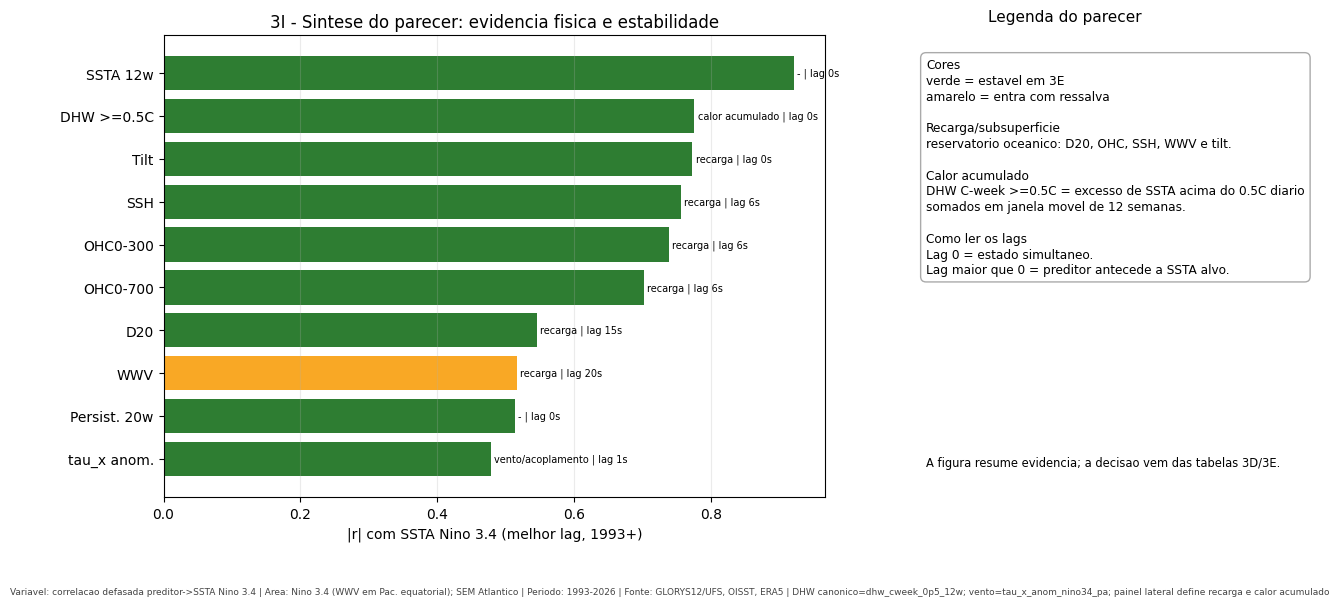

In [5]:
# figura-sintese: ranking com bloco e estabilidade
conc2=conc.sort_values('r',key=abs,ascending=False)
fig,(ax,ax_note)=plt.subplots(1,2,figsize=(13.5,6),gridspec_kw={'width_ratios':[2.4,1.05]})
cor=conc2['estavel_3E'].map({True:'#2e7d32',False:'#f9a825'})
y=np.arange(len(conc2))
ax.barh(y,conc2['r'].abs(),color=cor)
ax.set_yticks(y); ax.set_yticklabels(conc2['rotulo'])
for i,(_,r) in enumerate(conc2.iterrows()):
    ax.text(abs(r['r'])+.005,i,f"{r['bloco'].replace('recarga/subsuperficie','recarga')} | lag {r['lag_semanas']}s",va='center',fontsize=7)
ax.invert_yaxis(); ax.set_xlabel('|r| com SSTA Nino 3.4 (melhor lag, 1993+)')
ax.set_title('3I - Sintese do parecer: evidencia fisica e estabilidade')
ax.grid(axis='x',alpha=.25)
ax_note.axis('off')
ax_note.set_title('Legenda do parecer',fontsize=11,pad=10)
legend_txt=(
    'Cores\n'
    'verde = estavel em 3E\n'
    'amarelo = entra com ressalva\n\n'
    'Recarga/subsuperficie\n'
    'reservatorio oceanico: D20, OHC, SSH, WWV e tilt.\n\n'
    'Calor acumulado\n'
    'DHW C-week >=0.5C = excesso de SSTA acima do 0.5C diario\n'
    'somados em janela movel de 12 semanas.\n\n'
    'Como ler os lags\n'
    'Lag 0 = estado simultaneo.\n'
    'Lag maior que 0 = preditor antecede a SSTA alvo.'
)
ax_note.text(0.02,0.95,legend_txt,fontsize=8.7,va='top',ha='left',linespacing=1.28,
             bbox=dict(boxstyle='round,pad=.45',fc='white',ec='0.65',alpha=.95))
ax_note.text(0.02,0.06,'A figura resume evidencia; a decisao vem das tabelas 3D/3E.',fontsize=8.3,va='bottom',ha='left')
u.stamp_caption(fig,variavel='correlacao defasada preditor->SSTA Nino 3.4',area='Nino 3.4 (WWV em Pac. equatorial); SEM Atlantico',periodo='1993-2026',fonte='GLORYS12/UFS, OISST, ERA5',extra='DHW canonico=dhw_cweek_0p5_12w; vento=tau_x_anom_nino34_pa; painel lateral define recarga e calor acumulado')
u.save_fig(fig,'phase3I_sintese_parecer.png'); plt.show()


**Veredito integrado (Pacifico).** O **bloco de recarga/subsuperficie domina** o Nino 3.4: tilt/SSH/OHC descrevem o estado acoplado de curto prazo (lag 0-6 sem), **D20 e o melhor precursor estavel de medio prazo (~15 sem)**, tau_x_anom representa o acoplamento zonal do vento no crescimento. **WWV** entra com ressalva (regime-dependente pos-2010). **DHW** e severidade/memoria curta, nao precursor longo. A classificacao executiva da Fase 3 agora segue NOAA/ONI local: `fraco`, `moderado`, `forte`, `muito_forte`; o acoplamento atmosferico e tratado como proxy fisico local, nao como boletim oficial CPC. **2026:** aquecimento em curso, junho parcial - nao fecha evento ate completar a persistencia temporal. A Fase 3 sustenta parecer fisico, nao skill preditivo (isso e a Fase 5).


In [6]:
# exporta texto integrado atualizado para o parecer
entra = ', '.join(conc.query("uso_parecer == 'entra'")['variavel'].tolist())
ressalva = ', '.join(conc.query("uso_parecer != 'entra'")['variavel'].tolist())
estado = est.iloc[0]
linhas=[]
for _,r in media.iterrows():
    linhas.append(f"`{r['grupo']}`: n={int(r['n_eventos'])}, pico ONI medio {r['oni_pico_medio_c']} C, duracao media {r['duracao_media_estacoes_oni']} estacoes e DHW maximo medio {r['dhw_maximo_medio_c_weeks']} C-weeks.")
classes_txt = '\n\n'.join(linhas)
texto = f"""# Interpretacao integrada da Fase 3

## Veredito executivo
A Fase 3 sustenta um diagnostico fisico auditavel do Nino 3.4 com OISST local, sem ML. O bloco de recarga/subsuperficie (reservatorio oceanico: D20/OHC/SSH/WWV/tilt) domina a interpretacao: tilt/SSH/OHC descrevem o estado acoplado de curto prazo, D20 fornece antecedencia estavel de medio prazo e WWV aparece como relacao regime-dependente.

## Definicao NOAA/ONI local
Evento El Nino = media movel de 3 meses da SSTA Nino 3.4 >=+0.5 C por pelo menos 5 estacoes moveis sobrepostas. Intensidade = pico dessa media: fraco [0.5,1.0), moderado [1.0,1.5), forte [1.5,2.0), muito_forte >=2.0 C. O CPC/NOAA usa tambem evidencias atmosfericas; nesta Fase 3, o acoplamento atmosferico e avaliado por proxy local (`tau_x_anom_nino34_pa`), nao como declaracao oficial.

## DHW
O DHW canonico da Fase 3 e `dhw_cweek_0p5_12w`: soma em C-weeks de HotSpots diarios de SSTA >=+0.5 C em janela movel de 12 semanas. A consolidacao termica auxiliar exige media movel de 12 semanas >=+0.5 C por 20 semanas consecutivas.

## Relacoes que entram no parecer
Estaveis em 3D+3E: {entra}. Regime-dependentes/ressalva: {ressalva}. Relacoes instaveis entram como limitacao fisica, nao como descarte automatico.

## Classes NOAA
{classes_txt}

## Estado 2026
Ultimo dado diario OISST: {estado['ultimo_dia']}, SSTA diaria {estado['ssta_diaria_c']} C. Leitura: {estado['leitura']}.

## Proxima decisao
A Fase 3 pode alimentar um parecer fisico e preparar a Fase 5. Ela ainda nao prova skill preditivo. O proximo avanco deve testar se D20/OHC/SSH/tau_x_anom/DHW superam climatologia e persistencia em walk-forward.
"""
out = u.STATS / 'phase3I_interpretacao_integrada.md'
out.write_text(texto, encoding='utf-8')
print(f"[texto] {out.relative_to(u.ROOT)}")


[texto] data\processed\parquet\statistics\phase3I_interpretacao_integrada.md
